# **Detecção de forma OpenCV**

As descrições abaixo tem como objetivo reproduzir e estudar a implementação de detecção de formas geométricas apresentada no tutorial: [OpenCV Shape Detection - PyImageSearch](https://pyimagesearch.com/2016/02/08/opencv-shape-detection/).

Além da reprodução da implementação original, foram realizados testes com outra imagem com a finalidade de melhorar a implementação original, e no final foi discutido possíveis aplicações das técnicas utilizadas em outros problemas de visão computacional.

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

### **Detecção de formas** 

**detect(c)** é uma função responsável por analisar um contorno c e determinar qual forma geométrica ele representa. 

Primeiramente, a função calcula o perímetro do contorno, depois simplifica esse contorno utilizando approxPolyDP() e verifica quantos vértices existem nessa aproximação. 

A partir da quantidade de vértices, ela classifica a forma e retorna seu nome, como "triangle", "square" ou "circle".

---
**cv2.arcLength(c, True)**: é uma função utilizada para calcular o comprimento de um contorno, isto é, seu perímetro. 

O primeiro parâmetro é o contorno que queremos medir. O segundo parâmetro informa que o contorno deve ser considerado fechado, isso significa que o último ponto do contorno está conectado ao primeiro. 

---
**cv2.approxPolyDP(c, 0.04 * peri, True)**: é uma função utilizada para aproximar e simplificar um contorno. 

Um contorno real pode possuir muitos pontos, mesmo quando representa uma forma simples. Essa função tenta representar o contorno usando apenas os pontos mais importantes, formando uma aproximação poligonal. 

O primeiro parâmetro é o contorno original; o segundo, 0.04 * peri é o valor de tolerância da aproximação, chamado de **epsilon**; e o terceiro indica novamente que o contorno é fechado.

Uma atenção especial para o **epsilon**, pois esse valor determina o quanto o approxPolyDP() pode simplificar o contorno. Quanto maior o epsilon, maior pode ser a diferença entre o contorno original e a aproximação, fazendo com que menos pontos sejam utilizados. Quanto menor o epsilon, mais pontos serão preservados.

---

**cv2.boundingRect(approx):** é uma função que encontra o menor retângulo alinhado aos eixos da imagem capaz de envolver completamente o contorno fornecido. Ela retorna quatro valores: x, y, w e h. x e y representam a posição do canto superior esquerdo desse retângulo, enquanto w representa sua largura e h sua altura.

No tutorial essa função é utilizada apenas quando o contorno possui quatro vértices, porque ela conseguirá definir se a figura de quatro lados é mais parecida com um quadrado ou com um retângulo

ar = w / float(h): calcula a proporção entre a largura e a altura do retângulo que envolve a forma. Essa proporção é chamada de aspect ratio. Se w e h forem aproximadamente iguais, o resultado será próximo de 1, indicando uma forma aproximadamente quadrada. Se a largura for muito maior ou menor que a altura, o resultado ficará diferente de 1, indicando um retângulo.

shape = "square" if ar >= 0.95 and ar <= 1.05 else "rectangle": essa linha utiliza o valor do aspect ratio para diferenciar quadrados de retângulos. Se ar estiver entre 0.95 e 1.05, a forma é considerada um quadrado. Essa margem existe porque, em uma imagem real, pequenas distorções podem fazer com que um quadrado não apresente exatamente ar = 1. Caso o valor esteja fora desse intervalo, a forma é considerada um retângulo.

In [3]:
class ShapeDetector:
    def __init__(self):
        pass

    def detect(self, c):
        shape = "unidentified"
        peri = cv2.arcLength(c, True)
        approx = cv2.approxPolyDP(c, 0.04 * peri, True)

        if len(approx) == 3:
            shape = "triangle"

        elif len(approx) == 4:
            (x, y, w, h) = cv2.boundingRect(approx)

            ar = w/float(h)
            shape = "square" if ar>=0.95 and ar<= 1.05 else "rectangle"

        elif len(approx) == 5:
            shape = "pentagon"

        else:
            shape = "circle"

        return shape



### **Pré processamento**

Antes de encontrar os contornos, é necessário realizar um pré-processamento da imagem para facilitar a identificação das formas.

Primeiramente, a imagem é redimensionada utilizando um fator de escala. Esse redimensionamento reduz o tamanho da imagem, tornando o processamento mais rápido, mas mantendo sua proporção original.

In [4]:
image = cv2.imread("image/shapes_and_colors.jpg")

scale = 300 / image.shape[1]

new_width = int(image.shape[1] * scale)
new_height = int(image.shape[0] * scale)

resized = cv2.resize(image, (new_width, new_height))
ratio = 1 / scale

Em seguida, a imagem, que está originalmente no formato BGR é convertida para a escala de tons de cinza. 

Depois, é aplicado um desfoque gaussiano utilizando **cv2.GaussianBlur()** para suavizar a imagem e reduzir pequenos ruídos que poderiam interferir na identificação das formas.

In [5]:
gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

gaussian = cv2.GaussianBlur(gray, (5,5),0)


Na sequência, é aplicado um limiar utilizando **cv2.threshold()**. Essa operação transforma a imagem em uma representação binária e dessa forma, as regiões de interesse ficam destacadas, facilitando a identificação das formas.

In [6]:
ret, threshold = cv2.threshold(gaussian, 60, 255, cv2.THRESH_BINARY)


### **Encontrando os contornos**

Após esse pré-processamento, é utilizada a função **cv2.findContours()** para encontrar os contornos presentes na imagem binária. Cada contorno representa a borda de uma região identificada na imagem.

In [7]:
contornos, _ = cv2.findContours(threshold, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

Na estrutura for, os contornos encontrados são percorridos individualmente. Para cada contorno, são calculados seus momentos geométricos por meio de cv2.moments(), permitindo determinar as coordenadas (x, y) do centroide da forma.

Em seguida, o contorno é encaminhado ao objeto ShapeDetector, que utiliza o método detect() para identificar a forma geométrica. Nesse processo, o contorno é simplificado por meio de cv2.approxPolyDP(), possibilitando analisar a quantidade de vértices e classificar a forma.

Como os contornos foram extraídos da imagem redimensionada, as coordenadas do centroide e os pontos do contorno também estão nessa escala. Por isso, é necessário multiplicá-los pelo fator ratio, fazendo com que correspondam novamente às dimensões da imagem original.

Após essa conversão, cv2.drawContours() é utilizado para desenhar o contorno na imagem original, enquanto cv2.putText() insere o nome da forma próximo ao seu centroide.

In [8]:
sd = ShapeDetector()

for c in contornos:

    M = cv2.moments(c)

    if M["m00"] != 0:

        # Centro na imagem REDUZIDA
        cX = int(M["m10"] / M["m00"])
        cY = int(M["m01"] / M["m00"])

        # Identifica a forma
        shape = sd.detect(c)

        # Converte centro para a imagem ORIGINAL
        cX = int(cX * ratio)
        cY = int(cY * ratio)

        # Escala o contorno para a imagem original
        c_scaled = c.astype("float") * ratio
        c_scaled = c_scaled.astype("int")

        # Desenha contorno
        cv2.drawContours(image, [c_scaled], -1, (0, 255, 0), 2)

        # Escreve o nome no centro
        cv2.putText(image,shape,(cX - 20, cY),cv2.FONT_HERSHEY_SIMPLEX,0.5,(255, 255, 255),2)



(np.float64(-0.5), np.float64(599.5), np.float64(560.5), np.float64(-0.5))

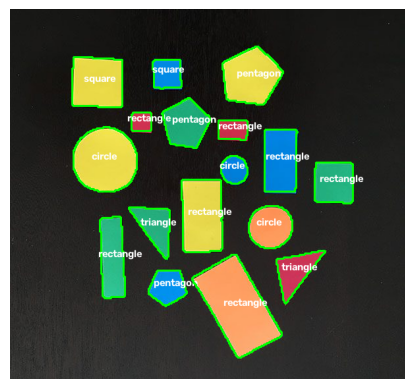

In [9]:
rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
cv2.imwrite("output/centro.png", rgb)
plt.imshow(rgb)

plt.axis('off')


In [25]:
def pre_processing(image):

    scale = 300 / image.shape[1]

    new_width = int(image.shape[1] * scale)
    new_height = int(image.shape[0] * scale)

    resized = cv2.resize(image, (new_width, new_height))

    ratio = 1 / scale

    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

    gaussian = cv2.GaussianBlur(gray, (5,5), 0)

    ret, threshold = cv2.threshold(gaussian, 60, 255, cv2.THRESH_BINARY)

    return threshold, ratio

def contour(threshold, image, ratio, sd, b, g, r):
    
    contornos, _ = cv2.findContours(threshold, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    for c in contornos:

        M = cv2.moments(c)

        if M["m00"] != 0:

            # Centro na imagem REDUZIDA
            cX = int(M["m10"] / M["m00"])
            cY = int(M["m01"] / M["m00"])

            # Identifica a forma
            shape = sd.detect(c)

            # Converte centro para a imagem ORIGINAL
            cX = int(cX * ratio)
            cY = int(cY * ratio)

            # Escala o contorno para a imagem original
            c_scaled = c.astype("float") * ratio
            c_scaled = c_scaled.astype("int")

            # Desenha contorno
            cv2.drawContours(image, [c_scaled], -1, (0, 255, 0), 2)

            # Escreve o nome no centro
            cv2.putText(image,shape,(cX - 20, cY),cv2.FONT_HERSHEY_SIMPLEX,0.5,(b, g, r),2)

    return image


### **Melhorias**

Uma limitação da implementação atual está na classificação das formas com mais de cinco vértices. Como a lógica utilizada considera qualquer forma que não possua 3, 4 ou 5 vértices como um círculo, formas diferentes de um círculo, como hexágonos e figuras irregulares, também acabam sendo classificadas como "circle". Abaixo um exemplo:

(np.float64(-0.5), np.float64(639.5), np.float64(326.5), np.float64(-0.5))

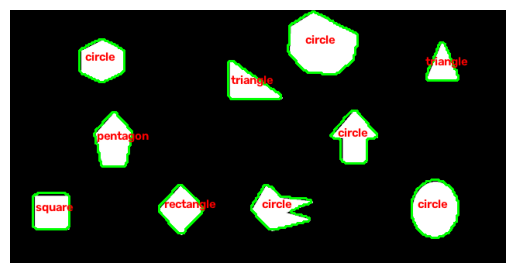

In [26]:
image2 = cv2.imread("image/formatos.png")

sd = ShapeDetector()

threshold, ratio = pre_processing(image2)

contornos2 = contour(threshold,image2,ratio,sd,0, 0, 255)

rgb = cv2.cvtColor(contornos2, cv2.COLOR_BGR2RGB)

cv2.imwrite("output/centro.png", rgb)

plt.imshow(rgb)
plt.axis('off')

Uma alternativa foi separar a identificação do círculo da quantidade de vértices. As formas conhecidas continuaram sendo classificadas pelo número de vértices. 

Porém, para as formas com mais de cinco vértices, em vez de assumir que se trata de um círculo, o algoritmo utiliza uma característica geométrica específica, como a circularidade, para verificar o quanto o contorno se aproxima de um círculo.

Caso a forma apresente características compatíveis com um círculo, ela será classificada como "circle". Caso contrário, poderá ser classificada genericamente como "other". Dessa maneira, um hexágono, uma seta ou uma forma irregular não será incorretamente identificada como círculo.

In [ ]:
#circularity = (4 * np.pi * area) / (peri ** 2)

----

A tentativa de incluir a identificação de círculos e hexágonos na implementação não deu muito certo.

Como a lógica inicial do ShapeDetector é baseada principalmente na quantidade de vértices obtidos pelo approxPolyDP(), utilizar um único valor global de epsilon acabou gerando classificações incorretas. O mesmo contorno poderia ser aproximado com diferentes quantidades de vértices dependendo da sua geometria, fazendo com que círculos fossem interpretados como hexágonos ou outras formas também apresentassem seis vértices.

Por isso, apenas aumentar ou diminuir o epsilon global não foi uma solução adequada.

Dessa forma, mantive o valor global e adicionei outras características geométricas, como circularidade e a proporção entre o menor e o maior lado.

**is_hexagon(approx)** é uma função auxiliar criada para diferenciar um hexágono de outras formas que também podem ser aproximadas por seis vértices. Ela recebe os seis pontos de approx, calcula o comprimento de cada lado e verifica se esses lados possuem tamanhos semelhantes.

ratio = min(sides) / max(sides): compara o menor lado com o maior. Se os lados forem semelhantes, o resultado será próximo de 1; se forem muito diferentes, será menor.

return ratio > 0.7: define que a forma será considerada um hexágono quando o menor lado tiver pelo menos 70% do tamanho do maior. Assim, o algoritmo não considera apenas os seis vértices, mas também verifica se a distribuição dos lados é compatível com um hexágono.


In [27]:
def is_hexagon(approx):

    sides = []

    for i in range(6):
        p1 = approx[i][0]
        p2 = approx[(i + 1) % 6][0]

        distance = np.linalg.norm(p2 - p1)
        sides.append(distance)

    ratio = min(sides) / max(sides)

    return ratio > 0.7

class ShapeDetector:
    def __init__(self):
        pass

    def detect(self, c):
        shape = "unidentified"
        peri = cv2.arcLength(c, True)
        approx = cv2.approxPolyDP(c, 0.04 * peri, True)

        if len(approx) == 3:
            shape = "triangle"

        elif len(approx) == 4:
            (x, y, w, h) = cv2.boundingRect(approx)

            ar = w/float(h)
            shape = "square" if ar>=0.95 and ar<= 1.05 else "rectangle"

        elif len(approx) == 5:
            shape = "pentagon"

        elif len(approx) == 6:

            area = cv2.contourArea(c)
            circularity = (4 * np.pi * area) / (peri ** 2)

            if not cv2.isContourConvex(approx):
                shape = "other"

            elif circularity > 0.88:
                shape = "circle"

            elif is_hexagon(approx):
                shape = "hexagon"

            else:
                shape = "other"
        else:

            area = cv2.contourArea(c)
            circularity = (4 * np.pi * area) / (peri ** 2)

            if circularity > 0.85:
                shape = "circle"
            else:
                shape = "other"
        return shape



In [28]:
def pre_processing(image):

    scale = 300 / image.shape[1]

    new_width = int(image.shape[1] * scale)
    new_height = int(image.shape[0] * scale)

    resized = cv2.resize(image, (new_width, new_height))

    ratio = 1 / scale

    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

    gaussian = cv2.GaussianBlur(gray, (5,5), 0)

    ret, threshold = cv2.threshold(gaussian, 60, 255, cv2.THRESH_BINARY)

    return threshold, ratio

def contour(threshold, image, ratio, sd, b, g, r):
    
    contornos, _ = cv2.findContours(threshold, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    for c in contornos:

        M = cv2.moments(c)

        if M["m00"] != 0:

            # Centro na imagem REDUZIDA
            cX = int(M["m10"] / M["m00"])
            cY = int(M["m01"] / M["m00"])

            # Identifica a forma
            shape = sd.detect(c)

            # Converte centro para a imagem ORIGINAL
            cX = int(cX * ratio)
            cY = int(cY * ratio)

            # Escala o contorno para a imagem original
            c_scaled = c.astype("float") * ratio
            c_scaled = c_scaled.astype("int")

            # Desenha contorno
            cv2.drawContours(image, [c_scaled], -1, (0, 255, 0), 2)

            # Escreve o nome no centro
            cv2.putText(image,shape,(cX - 20, cY),cv2.FONT_HERSHEY_SIMPLEX,0.5,(b, g, r),2)

    return image


(np.float64(-0.5), np.float64(639.5), np.float64(326.5), np.float64(-0.5))

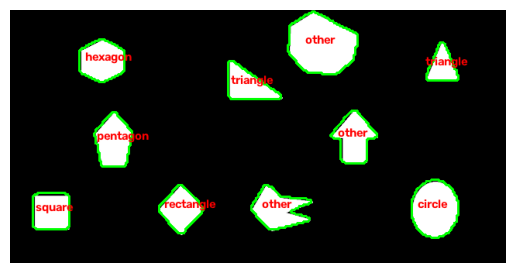

In [29]:
image2 = cv2.imread("image/formatos.png")

sd = ShapeDetector()

threshold, ratio = pre_processing(image2)

contornos2 = contour(threshold,image2,ratio,sd,0, 0, 255)

rgb = cv2.cvtColor(contornos2, cv2.COLOR_BGR2RGB)

cv2.imwrite("output/centro.png", rgb)

plt.imshow(rgb)
plt.axis('off')

Apesar da melhora na classificação, a solução ainda depende dos parâmetros utilizados na aproximação dos contornos e dos limiares definidos durante o pré-processamento.

Alterações na iluminação, ruído, escala ou geometria das formas podem alterar a quantidade de vértices obtidos por **approxPolyDP()**, afetando a classificação.

### **Aplicações**

A técnica de detecção de formas pode ser aplicada em sistemas de inspeção visual industrial, nos quais características geométricas dos componentes são utilizadas para verificar sua presença, posição ou conformidade.

Um exemplo seria a inspeção de tampas, lacres e componentes circulares. Nesse cenário, as etapas de pré-processamento, detecção de contornos, aproximação poligonal (approxPolyDP), cálculo de área, perímetro e circularidade podem ser utilizadas para localizar e caracterizar o componente. A partir dessas informações, seria possível verificar se o componente está presente, se possui formato esperado ou se apresenta alterações geométricas.